In [1]:
from fncs_helper import *
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import importlib
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import os
import random
from torch.utils.data import TensorDataset, DataLoader
import torch.utils.data as data_utils

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
DEVICE = torch.device("cuda:0")

In [44]:
dataFolder = './Data/'
dirTrain = dataFolder + 'Train/'

timeStep = 1
winSz = 2

In [45]:
valIDs = [2,11,18,20,25]      #2,11,25
trainIDs = list(set(np.array(range(25))+1).difference(valIDs))

xTrain, yTrain = load_data(dirTrain,winSz,timeStep,trainIDs)
xVal, yVal = load_data(dirTrain,winSz,timeStep,valIDs[:3])

# If Conv2D model used ##
xTrain = xTrain.reshape(-1,1,xTrain.shape[1],xTrain.shape[2])
xVal = xVal.reshape(-1,1,xVal.shape[1],xVal.shape[2])

xTrain = xTrain / np.max(xTrain)
xVal = xVal / np.max(xVal)

Xtrain_tensor = torch.tensor(xTrain, dtype=torch.float32)
Ytrain_tensor = torch.tensor(yTrain, dtype=torch.long)

Xtrain_tensor = Xtrain_tensor.to(DEVICE)
Ytrain_tensor = Ytrain_tensor.to(DEVICE)

dataset = TensorDataset(Xtrain_tensor,Ytrain_tensor)

dataloader = DataLoader(dataset, batch_size=30, shuffle=True)

In [46]:
Xtrain_tensor.shape

torch.Size([23518, 1, 80, 6])

In [48]:
class PropNet(nn.Module):

    def __init__(self,num_classes=4):
        super(PropNet,self).__init__()        

        self.conv2Dblock = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32,16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.linearblock = nn.Sequential(
            nn.Linear(16 * 38 * 1, 256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )


    def forward(self,x):
    
        x = self.conv2Dblock(x)
        x = x.view(x.size(0), -1)
        x = self.linearblock(x)


        return x
    
    def predict(self,X):
        # X = torch.from_numpy(X).float()
        # X = X.to(DEVICE)
        # Output = self.forward(X)
        # Output = Output.cpu().detach().numpy()
        # Yhat = np.argmax(Output,axis=1)
        self.eval()
        with torch.no_grad():
            outputs = self.forward(X)
            Yhat = torch.argmax(outputs, dim=1)
            Yhat = Yhat.cpu().numpy()

        return Yhat

weights = [0.3, 0.45, 0.45, 1.0]    
model = PropNet().to(DEVICE)
criterion = nn.CrossEntropyLoss(weight = torch.tensor(weights).to(DEVICE))
# criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
            

In [49]:
summary(model,xTrain.shape[1:])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 32, 78, 4]             320
              ReLU-2            [-1, 32, 78, 4]               0
            Conv2d-3            [-1, 16, 76, 2]           4,624
              ReLU-4            [-1, 16, 76, 2]               0
         MaxPool2d-5            [-1, 16, 38, 1]               0
            Linear-6                  [-1, 256]         155,904
              ReLU-7                  [-1, 256]               0
            Linear-8                  [-1, 128]          32,896
              ReLU-9                  [-1, 128]               0
           Linear-10                    [-1, 4]             516
Total params: 194,260
Trainable params: 194,260
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.20
Params size (MB): 0.74
Estimated T

In [50]:
def train_model(model,dataloader, Xval, Yval, criterion, optimizer, num_epochs=25):
    
    train_acc = []
    val_acc = []
    train_loss = []
    val_loss = []

    Xval = torch.from_numpy(Xval).float()
    Yval = torch.from_numpy(Yval).long()
    Xval = Xval.to(DEVICE)
    Yval = Yval.to(DEVICE)
    
    for epoch in range(num_epochs):
        
        model.train()

        train_acc_values = []
        train_loss_values = []
        for X_b, Y_b in dataloader:
            
            outputs = model(X_b)
            loss = criterion(outputs,Y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # pred = outputs.cpu().detach().numpy()
            # pred = np.argmax(pred,axis=1)
            pred = model.predict(X_b)
            
            # train_accuracy = metrics.accuracy_score(Y_b.cpu().numpy(),pred) 
            train_accuracy = np.sum(Y_b.cpu().numpy()==pred)/len(pred)
            train_acc_values.append(train_accuracy)
            train_loss_values.append(loss.item())


        model.eval()

        outputs = model(Xval)
        valid_loss = criterion(outputs,Yval)

        # pred = outputs.cpu().detach().numpy()
        # pred = np.argmax(pred,axis=1)  
        pred = model.predict(Xval) 
        # validation_accuracy = metrics.accuracy_score(Yval.cpu().numpy(),pred) 
        validation_accuracy = np.sum(Yval.cpu().numpy()==pred)/len(pred)
       


        train_acc.append(sum(train_acc_values)/len(train_acc_values))
        val_acc.append(validation_accuracy)
        train_loss.append(sum(train_loss_values)/len(train_loss_values))
        val_loss.append(valid_loss.item())

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {sum(train_loss_values)/len(train_loss_values): .4f}, Val Loss: {valid_loss: .4f}")
        print(f"Train Accuracy: {sum(train_acc_values)/len(train_acc_values): .4f}, Val Accuracy: {validation_accuracy: .4f}")
        print(f"----------------")


    history = [train_acc,val_acc,train_loss,val_loss]
    
    return model, history

In [51]:
model, history = train_model(model, dataloader,xVal,yVal,criterion,optimizer,num_epochs=10)

Epoch [1/10]
Train Loss:  0.6853, Val Loss:  0.5569
Train Accuracy:  0.7833, Val Accuracy:  0.8692
----------------
Epoch [2/10]
Train Loss:  0.3607, Val Loss:  0.3346
Train Accuracy:  0.8881, Val Accuracy:  0.9169
----------------
Epoch [3/10]
Train Loss:  0.2665, Val Loss:  0.5205
Train Accuracy:  0.9220, Val Accuracy:  0.9057
----------------
Epoch [4/10]
Train Loss:  0.2265, Val Loss:  0.3464
Train Accuracy:  0.9315, Val Accuracy:  0.9301
----------------
Epoch [5/10]
Train Loss:  0.2023, Val Loss:  0.5266
Train Accuracy:  0.9405, Val Accuracy:  0.9148
----------------
Epoch [6/10]
Train Loss:  0.1709, Val Loss:  0.4487
Train Accuracy:  0.9497, Val Accuracy:  0.9244
----------------
Epoch [7/10]
Train Loss:  0.1504, Val Loss:  0.3876
Train Accuracy:  0.9576, Val Accuracy:  0.9360
----------------
Epoch [8/10]
Train Loss:  0.1361, Val Loss:  0.4261
Train Accuracy:  0.9615, Val Accuracy:  0.9262
----------------
Epoch [9/10]
Train Loss:  0.1163, Val Loss:  0.4797
Train Accuracy:  0.9

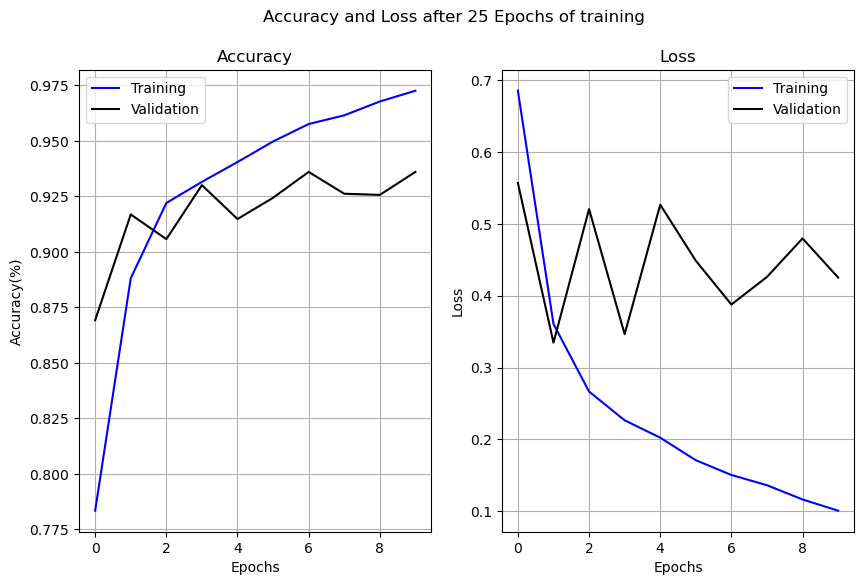

In [52]:
def history_plotter(history,epochs=10):

    num_epochs = epochs
    acc = history[0]
    validation_acc = history[1]
    train_loss = history[2]
    val_loss = history[3]

    fig, ax = plt.subplots(1,2,figsize=(10,6))
    fig.suptitle("Accuracy and Loss after 25 Epochs of training")

    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy(%)")
    ax[0].set_title("Accuracy")
    ax[0].plot(range(num_epochs),acc,color='b',label='Training')
    ax[0].plot(range(num_epochs),validation_acc,color='k',label='Validation')
    ax[0].legend()
    ax[0].grid()

    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].set_title("Loss")
    ax[1].plot(range(num_epochs),train_loss,color='b',label='Training')
    ax[1].plot(range(num_epochs),val_loss,color='k',label='Validation')
    ax[1].legend()
    ax[1].grid()

history_plotter(history)

RESULTS:

Training:  Acc = 0.962
Training:  BalAcc = 0.975
Validation: Acc = 0.936
Validation: BalAcc = 0.894


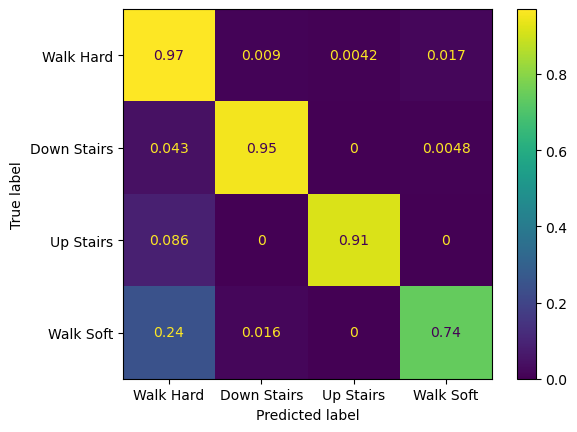

In [53]:
yTrainHat1 = model.predict(torch.from_numpy(xTrain).float().to(DEVICE))
yValHat1 = model.predict(torch.from_numpy(xVal).float().to(DEVICE))


print('RESULTS:\n')
summaryPerf(yTrain,yTrainHat1,yVal,yValHat1)

In [58]:
save = 1
if save == 1:
    torch.save(model.state_dict(),'model_opt.pth')

C:\Users\rjahani\AppData\Local\Temp\ipykernel_6520\2780217865.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_opt.load_state_dict(torch.load('model_opt.pth'))


RESULTS:

Training:  Acc = 0.962
Training:  BalAcc = 0.975
Validation: Acc = 0.936
Validation: BalAcc = 0.894


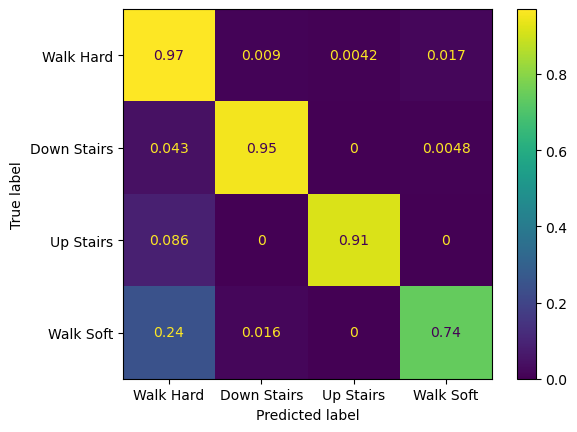

In [59]:
model_opt = PropNet().to(DEVICE)
model_opt.load_state_dict(torch.load('model_opt.pth'))


yTrainHat1 = model_opt.predict(torch.from_numpy(xTrain).float().to(DEVICE))
yValHat1 = model_opt.predict(torch.from_numpy(xVal).float().to(DEVICE))


print('RESULTS:\n')
summaryPerf(yTrain,yTrainHat1,yVal,yValHat1)

## Confirming The Model has learnt

In [13]:
xt, xv, yt, yv = loadTrial_Train(dirTrain,25)

In [14]:
X,Y = extractWin(xt,xv,yt,yv,winSz,timeStep)
X = X/np.max(X)
X = X.reshape(-1,1,X.shape[1],X.shape[2])
X = torch.from_numpy(X).float().to(DEVICE)
Yhat = model.predict(X)
metrics.accuracy_score(Yhat,Y)

0.9379450661241099

In [54]:
acc_avg = 0
c = 0
for i in trainIDs:
    X, Y = load_data(dirTrain,winSz,timeStep,[i])
    X = X.reshape(-1,1,X.shape[1],X.shape[2])
    X = X/np.max(X)
    X = torch.from_numpy(X).float().to(DEVICE)
    Y_pred = model.predict(X)
    acc = metrics.accuracy_score(Y_pred,Y)
    acc_avg += acc
    c += 1

acc_avg/c

0.9638841587480655

In [55]:
X, Y = load_data(dirTrain,winSz,timeStep,valIDs[:3])
X = X.reshape(-1,1,X.shape[1],X.shape[2])
X = X/np.max(X)
X = torch.from_numpy(X).float().to(DEVICE)
pred_val = model.predict(X)
acc = metrics.accuracy_score(Y,pred_val)
acc

0.936026936026936

In [57]:
X, Y = load_data(dirTrain,winSz,timeStep,valIDs[3:])
X = X.reshape(-1,1,X.shape[1],X.shape[2])
X = X/np.max(X)
X = torch.from_numpy(X).float().to(DEVICE)
pred_val = model.predict(X)
acc = metrics.balanced_accuracy_score(Y,pred_val)
acc

0.9631936038614588

## Generating the test output

In [60]:
def trial_read(testcase,trial_id):
    dataFolder = f'./Data/Test{testcase}/'
    xt = np.genfromtxt('{}trial{:02d}.x.t.csv'.format(dataFolder,trial_id),delimiter=',')
    xv = np.genfromtxt('{}trial{:02d}.x.v.csv'.format(dataFolder,trial_id),delimiter=',')
    yt = np.genfromtxt('{}trial{:02d}.y.t.csv'.format(dataFolder,trial_id),delimiter=',')

    return xt,xv,yt

def yv_prediction(testcase,trial_id,model):

    xt, xv, yt = trial_read(testcase,trial_id)

    timeStart = np.min(xt)
    timeEnd = np.max(xt)

    X = extract_features(xt,xv,winSz,timeStep,timeStart,timeEnd)

    X = X.reshape(-1,1,X.shape[1],X.shape[2])
    X = X/np.max(X)
    X = torch.from_numpy(X).float().to(DEVICE)

    y = model.predict(X)


    timeStart = np.min(yt)
    timeEnd = np.max(yt)
    t0 = timeStart
    t1 = t0 + winSz

    yv = np.zeros(len(yt))
    i = 0
    while(t1 <= timeEnd):
        
        yv[(yt>=t0)*(yt<=t1)] = int(y[i])

        t0 = t0 + timeStep
        t1 = t0 + winSz
        i = i + 1

    return yv

def yv_write(test_case,trial_id,model):

    dst_path = f'./Test{test_case}-Pred/'
    path = '{}trial{:02d}.y.v.csv'.format(dst_path,trial_id)

    yv = yv_prediction(test_case,trial_id,model)

    np.savetxt(path, yv, delimiter=',',fmt='%d')

    return yv


In [61]:
model_opt = PropNet().to(DEVICE)
model_opt.load_state_dict(torch.load('model_opt.pth'))

C:\Users\rjahani\AppData\Local\Temp\ipykernel_6520\1255752963.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_opt.load_state_dict(torch.load('model_opt.pth'))


<All keys matched successfully>

In [62]:
for testcase in [1,2]:
    for trial_id in [1,2,3,4]:
        yv = yv_write(testcase,trial_id,model)

## Testing a couple of data regeneration

In [63]:
def trial_read(trial_id):
    dataFolder = f'./Data/Train/'
    xt = np.genfromtxt('{}trial{:02d}.x.t.csv'.format(dataFolder,trial_id),delimiter=',')
    xv = np.genfromtxt('{}trial{:02d}.x.v.csv'.format(dataFolder,trial_id),delimiter=',')
    yt = np.genfromtxt('{}trial{:02d}.y.t.csv'.format(dataFolder,trial_id),delimiter=',')
    yv = np.genfromtxt('{}trial{:02d}.y.v.csv'.format(dataFolder,trial_id),delimiter=',')

    return xt,xv,yt,yv

def yv_prediction(trial_id,model):

    xt, xv, yt, yv = trial_read(trial_id)

    timeStart = np.min(xt)
    timeEnd = np.max(xt)

    X = extract_features(xt,xv,winSz,timeStep,timeStart,timeEnd)

    X = X.reshape(-1,1,X.shape[1],X.shape[2])
    X = X/np.max(X)
    X = torch.from_numpy(X).float().to(DEVICE)

    y = model.predict(X)


    timeStart = np.min(yt)
    timeEnd = np.max(yt)
    t0 = timeStart
    t1 = t0 + winSz

    yv_hat = np.zeros(len(yt))
    i = 0
    while(t1 <= timeEnd):
        
        yv_hat[(yt>=t0)*(yt<=t1)] = int(y[i])

        t0 = t0 + timeStep
        t1 = t0 + winSz
        i = i + 1

    return yv,yv_hat

0.890839651142906

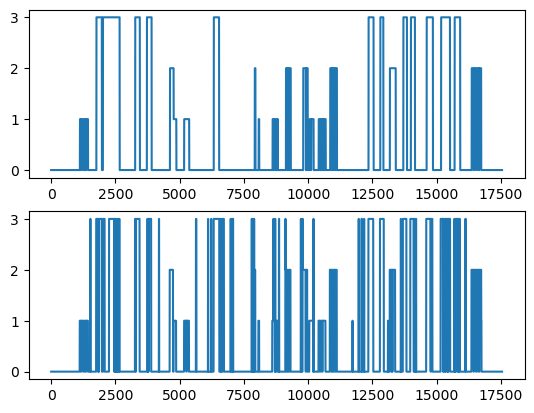

In [64]:
yv,yv_hat = yv_prediction(2,model)
plt.subplot(2,1,1)
plt.plot(yv)
plt.subplot(2,1,2)
plt.plot(yv_hat)
np.sum(yv==yv_hat)/len(yv)

In [65]:
avg = 0
for i in valIDs[3:]:
    # yv,yv_hat = yv_prediction(i,model_opt)
    # acc_opt = np.sum(yv==yv_hat)/len(yv)
    yv,yv_hat = yv_prediction(i,model)
    # acc = np.sum(yv==yv_hat)/len(yv)
    acc = metrics.balanced_accuracy_score(yv,yv_hat)
    print(acc)
    avg += acc
print(f"Avg Acc:{avg/2: 0.4f}")
    # print(acc>acc_opt)

0.9410390324031411
0.9265603219917184
Avg Acc: 0.9338


In [67]:
avg = 0
for i in valIDs[:3]:
    # yv,yv_hat = yv_prediction(i,model_opt)
    # acc_opt = np.sum(yv==yv_hat)/len(yv)
    yv,yv_hat = yv_prediction(i,model)
    # acc = np.sum(yv==yv_hat)/len(yv)
    acc = metrics.balanced_accuracy_score(yv,yv_hat)
    print(acc)
    avg += acc
print(f"Avg Acc:{avg/3: 0.4f}")
    # print(acc>acc_opt)

0.8490593302196587
0.8640661287352853
0.8635290658259007
Avg Acc: 0.8589


In [68]:
avg = 0
for i in trainIDs:
    # yv,yv_hat = yv_prediction(i,model_opt)
    # acc_opt = np.sum(yv==yv_hat)/len(yv)
    yv,yv_hat = yv_prediction(i,model)
    # acc = np.sum(yv==yv_hat)/len(yv)
    acc = metrics.balanced_accuracy_score(yv,yv_hat)
    print(acc)
    avg += acc
print(f"Avg Acc:{avg/20: 0.4f}")
    # print(acc>acc_opt)

0.917640061855192
0.913265130733458
0.9007930275918374
0.9052482921345626
0.9169398346215107
0.7485650196485433
0.932473367323938
0.9273683295484333
0.9185555233308655
0.8902839750836966
0.9377786745844178


c:\Users\rjahani\.conda\envs\torch_env\lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


0.9149576208539013
0.9420400766067926
0.945681288921816
0.9204136628762676
0.9354415747064908
0.9349889553644685
0.9522943138217465
0.9440815830754942
0.9422079096932121
Avg Acc: 0.9171
